# Initializing The Environment

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime
import os

In [2]:
# Initialize Spark with optimized settings for your laptop
spark = SparkSession.builder \
    .appName("TPC-H Comprehensive EDA") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .config("spark.sql.parquet.compression.codec", "snappy") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.autoBroadcastJoinThreshold", "10485760") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

# Set log level to reduce noise
spark.sparkContext.setLogLevel("WARN")

# Define path to your Parquet files
data_path = "/home/jovyan/data/tpch-sf1-parquet/"

In [3]:
# Set log level to reduce noise
spark.sparkContext.setLogLevel("WARN")

# Define path to your Parquet files
data_path = "/home/jovyan/data/raw/tables/original/"

print("="*80)
print("TPC-H COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)
print(f"Data path: {data_path}")
print(f"Spark version: {spark.version}")
print("="*80)

TPC-H COMPREHENSIVE EXPLORATORY DATA ANALYSIS
Data path: /home/jovyan/data/raw/tables/original/
Spark version: 3.4.1


# Load All Tables and Basic Information

In [4]:
def load_all_tables(spark, data_path):
    """Load all TPC-H tables from Parquet files"""
    
    tables = {}
    table_files = os.listdir(data_path)
    
    print("\n📂 LOADING TABLES:")
    print("-" * 40)
    
    for file in table_files:
        if file.endswith('.parquet'):
            table_name = file.replace('.parquet', '')
            full_path = os.path.join(data_path, file)
            
            # Read parquet file
            df = spark.read.parquet(full_path)
            tables[table_name] = df
            
            # Cache small dimension tables
            if table_name in ['region', 'nation', 'part', 'supplier', 'customer']:
                df.cache()
                df.count()  # Force cache
            
            print(f"  ✅ {table_name:12}: {df.count():12,} rows, {len(df.columns):2} columns")
    
    return tables

In [5]:
# Load all tables
tables = load_all_tables(spark, data_path)


📂 LOADING TABLES:
----------------------------------------
  ✅ customer    :      150,000 rows,  8 columns
  ✅ lineitem    :    6,001,215 rows, 16 columns
  ✅ nation      :           25 rows,  4 columns
  ✅ orders      :    1,500,000 rows,  9 columns
  ✅ part        :      200,000 rows,  9 columns
  ✅ partsupp    :      800,000 rows,  5 columns
  ✅ region      :            5 rows,  3 columns
  ✅ supplier    :       10,000 rows,  7 columns


# Data Quality Assessment

In [6]:
def assess_data_quality(tables):
    """Check data quality metrics for each table"""
    
    print("\n🔍 DATA QUALITY ASSESSMENT:")
    print("=" * 80)
    
    quality_report = {}
    
    for table_name, df in tables.items():
        print(f"\n📊 Table: {table_name.upper()}")
        print("-" * 60)
        
        # Basic stats
        total_rows = df.count()
        
        # Check for nulls in each column
        null_checks = []
        for col_name in df.columns:
            null_count = df.filter(col(col_name).isNull()).count()
            null_pct = (null_count / total_rows) * 100
            if null_count > 0:
                null_checks.append(f"    {col_name}: {null_count:,} nulls ({null_pct:.2f}%)")
        
        # Check for duplicates (if primary key exists)
        pk_columns = {
            'lineitem': ['l_orderkey', 'l_linenumber'],
            'orders': ['o_orderkey'],
            'customer': ['c_custkey'],
            'part': ['p_partkey'],
            'supplier': ['s_suppkey'],
            'partsupp': ['ps_partkey', 'ps_suppkey'],
            'nation': ['n_nationkey'],
            'region': ['r_regionkey']
        }
        
        if table_name in pk_columns:
            pk_cols = pk_columns[table_name]
            distinct_count = df.select(*pk_cols).distinct().count()
            if distinct_count != total_rows:
                print(f"  ⚠️  Primary key issue: {distinct_count:,} unique vs {total_rows:,} rows")
        
        # Print null checks
        if null_checks:
            print("  ⚠️  Null values found:")
            for check in null_checks:
                print(check)
        else:
            print("  ✅ No null values found")
        
        # Column statistics
        print("\n  📈 Column Statistics:")
        for col_name in df.columns[:5]:  # First 5 columns only
            if df.schema[col_name].dataType in [IntegerType(), LongType(), DoubleType(), FloatType()]:
                stats = df.agg(
                    min(col_name).alias('min'),
                    max(col_name).alias('max'),
                    avg(col_name).alias('avg')
                ).collect()[0]
                print(f"    {col_name}: min={stats['min']}, max={stats['max']}, avg={stats['avg']:.2f}")

In [7]:
assess_data_quality(tables)


🔍 DATA QUALITY ASSESSMENT:

📊 Table: CUSTOMER
------------------------------------------------------------
  ✅ No null values found

  📈 Column Statistics:
    c_custkey: min=1, max=150000, avg=75000.50
    c_nationkey: min=0, max=24, avg=12.01

📊 Table: LINEITEM
------------------------------------------------------------
  ✅ No null values found

  📈 Column Statistics:
    l_orderkey: min=1, max=6000000, avg=3000279.60
    l_partkey: min=1, max=200000, avg=100017.99
    l_suppkey: min=1, max=10000, avg=5000.60
    l_linenumber: min=1, max=7, avg=3.00

📊 Table: NATION
------------------------------------------------------------
  ✅ No null values found

  📈 Column Statistics:
    n_nationkey: min=0, max=24, avg=12.00
    n_regionkey: min=0, max=4, avg=2.00

📊 Table: ORDERS
------------------------------------------------------------
  ✅ No null values found

  📈 Column Statistics:
    o_orderkey: min=1, max=6000000, avg=2999991.50
    o_custkey: min=1, max=149999, avg=75006.04

📊 Tab

# Checking the columns distributions

In [8]:
# Diagnostic code - run this before your plotting function
print("="*50)
print("DIAGNOSTIC INFORMATION")
print("="*50)

for table_name, df in tables.items():
    print(f"\n📋 Table: {table_name}")
    print(f"Number of columns: {len(df.columns)}")
    
    # Show column names and their data types
    print("\nColumns and types:")
    for field in df.schema.fields:
        print(f"  • {field.name}: {field.dataType}")
    
    # Show sample of first few rows for numeric columns
    print("\nSample data (first 2 rows):")
    sample = df.limit(2).toPandas()
    for col in sample.columns:
        if sample[col].dtype in ['int64', 'float64']:
            print(f"  {col}: {sample[col].tolist()}")
    
    print("-"*40)

DIAGNOSTIC INFORMATION

📋 Table: customer
Number of columns: 8

Columns and types:
  • c_custkey: LongType()
  • c_name: StringType()
  • c_address: StringType()
  • c_nationkey: IntegerType()
  • c_phone: StringType()
  • c_acctbal: DecimalType(15,2)
  • c_mktsegment: StringType()
  • c_comment: StringType()

Sample data (first 2 rows):
  c_custkey: [1, 2]
----------------------------------------

📋 Table: lineitem
Number of columns: 16

Columns and types:
  • l_orderkey: LongType()
  • l_partkey: LongType()
  • l_suppkey: LongType()
  • l_linenumber: LongType()
  • l_quantity: DecimalType(15,2)
  • l_extendedprice: DecimalType(15,2)
  • l_discount: DecimalType(15,2)
  • l_tax: DecimalType(15,2)
  • l_returnflag: StringType()
  • l_linestatus: StringType()
  • l_shipdate: DateType()
  • l_commitdate: DateType()
  • l_receiptdate: DateType()
  • l_shipinstruct: StringType()
  • l_shipmode: StringType()
  • l_comment: StringType()

Sample data (first 2 rows):
  l_orderkey: [1, 1]
  l_pa

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql.functions import col

def plot_single_table(tables, table_name, plot_cols):
    """
    Custom function to plot a single table based on your request
    """
    sns.set_style("whitegrid")
    
    if table_name not in tables:
        print(f"⚠️ Table '{table_name}' not found.")
        return
        
    df = tables[table_name]
    actual_cols = [c for c in plot_cols if c in df.columns]
    
    if not actual_cols:
        print(f"⚠️ No matching columns to plot in table '{table_name}'.")
        return
        
    print(f"\n📊 {table_name.upper()} - {len(actual_cols)} columns")
    
    n_cols = len(actual_cols)
    n_rows = (n_cols + 1) // 2 
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4*n_rows))
    if n_rows == 1:
        axes_flat = axes
    else:
        axes_flat = axes.flatten()
        
    fig.suptitle(f'TPC-H {table_name.upper()} Distributions', fontsize=14, fontweight='bold')
    
    for idx, column in enumerate(actual_cols):
        ax = axes_flat[idx]
        sample = df.select(column).limit(5000).toPandas().dropna()
        
        if len(sample) == 0:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax.set_title(column)
            continue
        
        try:
            numeric_vals = pd.to_numeric(sample[column], errors='coerce').dropna()
            if len(numeric_vals) > 0 and numeric_vals.dtype in ['int64', 'float64']:
                sns.histplot(x=numeric_vals.values, bins=30, color='steelblue', ax=ax)
                ax.set_xlabel(column)
            else:
                val_counts = sample[column].astype(str).value_counts().head(8)
                sns.barplot(x=val_counts.index, y=val_counts.values, color='coral', ax=ax)
                ax.set_xlabel(column)
                ax.tick_params(axis='x', rotation=45)
        except:
            val_counts = sample[column].astype(str).value_counts().head(8)
            sns.barplot(x=val_counts.index, y=val_counts.values, color='coral', ax=ax)
            ax.set_xlabel(column)
            ax.tick_params(axis='x', rotation=45)
        
        ax.set_ylabel('Count')
        ax.set_title(column)
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplots if the number of columns is odd
    for idx in range(len(actual_cols), len(axes_flat)):
        fig.delaxes(axes_flat[idx])
        
    plt.tight_layout()
    plt.show()


📊 LINEITEM - 4 columns


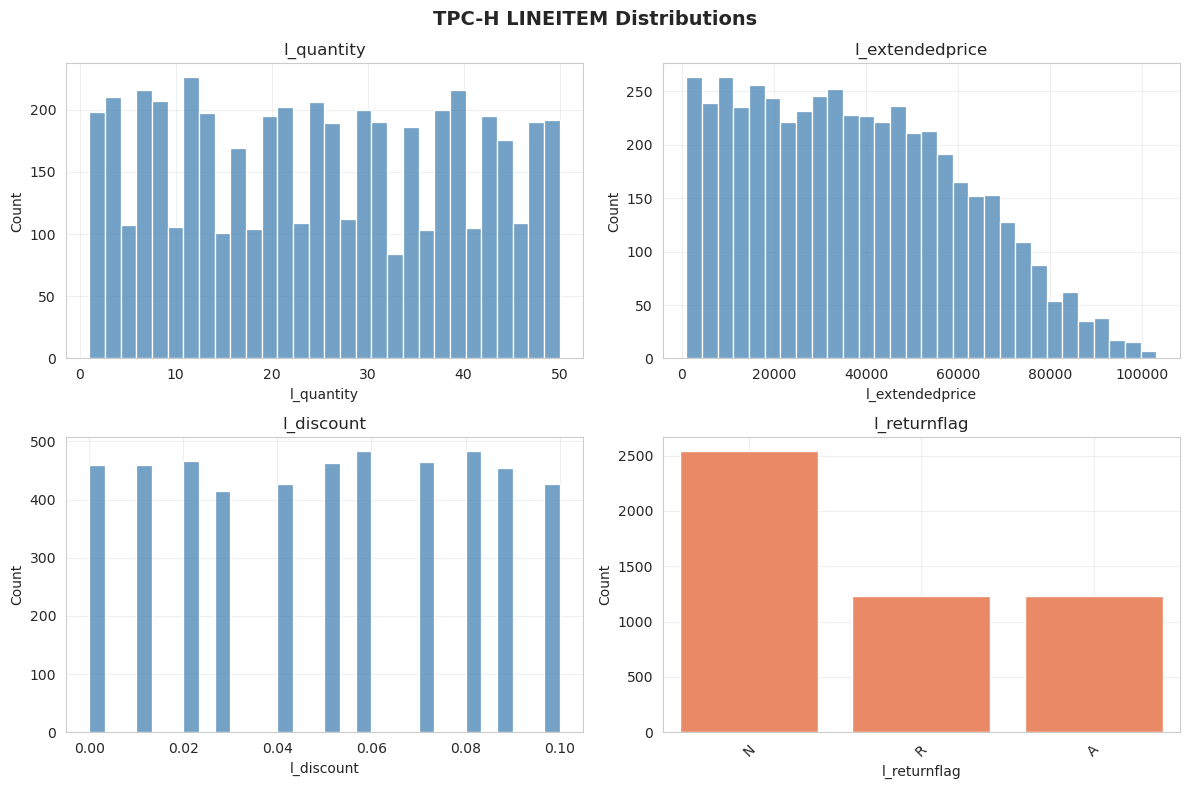

In [10]:
cols = ['l_quantity', 'l_extendedprice', 'l_discount', 'l_returnflag']
plot_single_table(tables, 'lineitem', cols)


📊 ORDERS - 3 columns


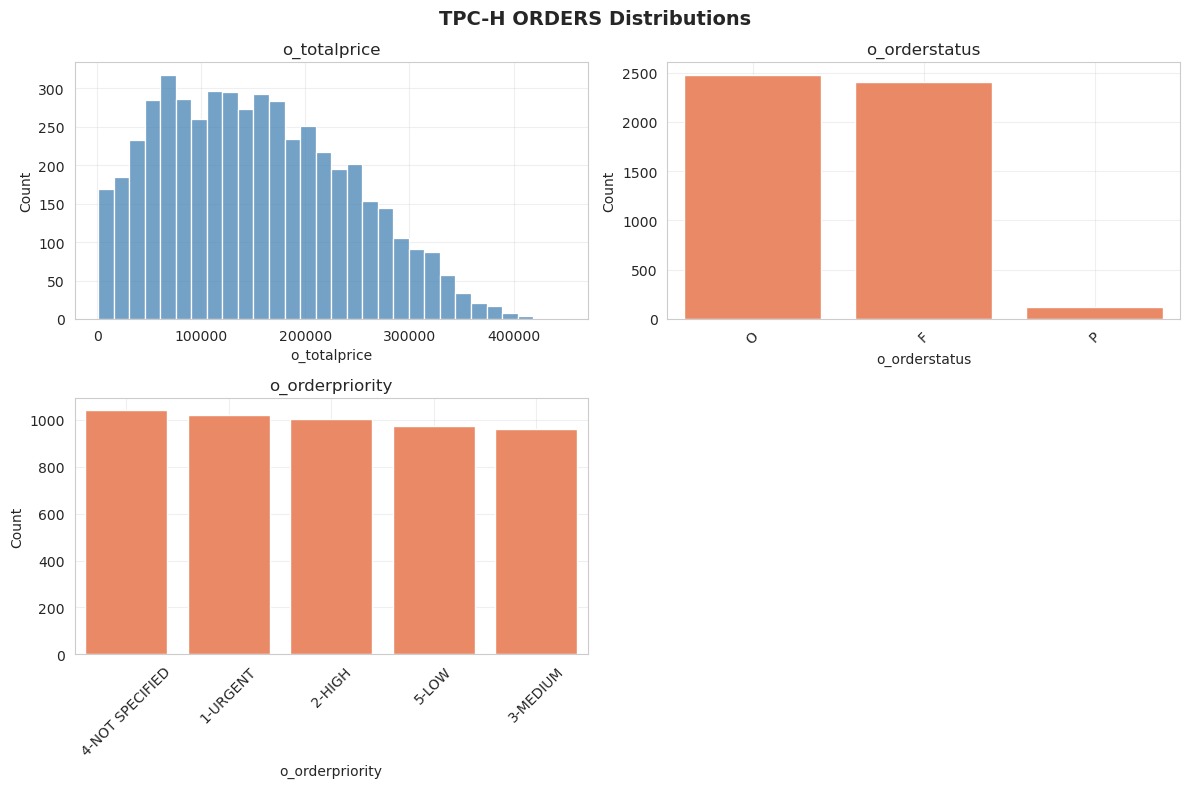

In [11]:
orders_cols = ['o_totalprice', 'o_orderstatus', 'o_orderpriority']
plot_single_table(tables, 'orders', orders_cols) 


📊 CUSTOMER - 2 columns


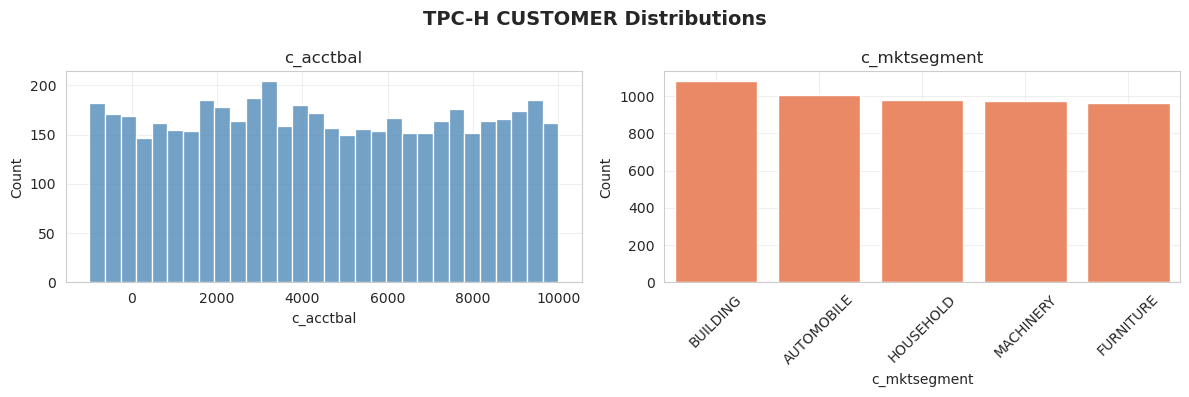

In [12]:
customer_cols = ['c_acctbal', 'c_mktsegment']
plot_single_table(tables, 'customer', customer_cols)


📊 SUPPLIER - 1 columns


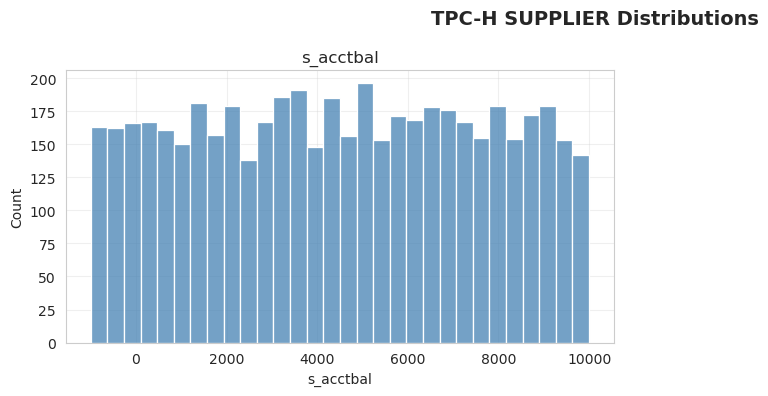

In [13]:
supplier_cols = ['s_acctbal']
plot_single_table(tables, 'supplier', supplier_cols)


📊 PARTSUPP - 2 columns


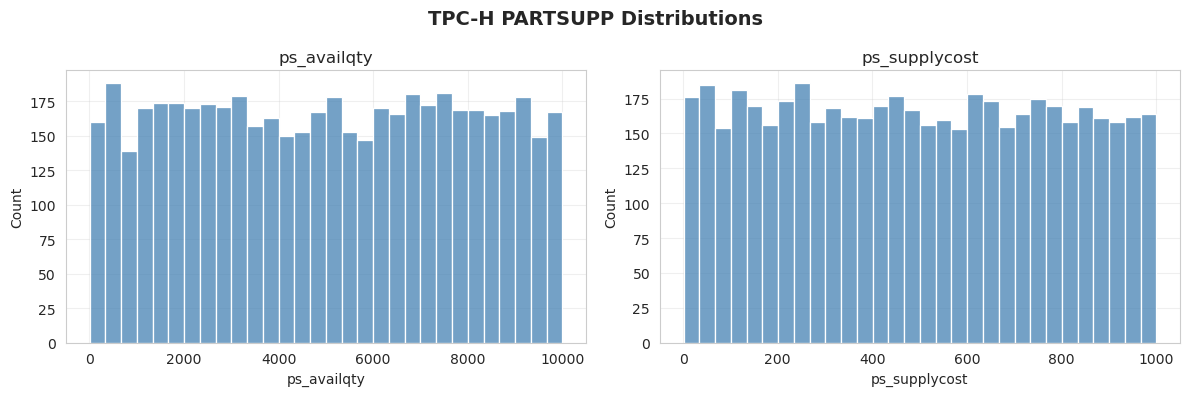

In [14]:
partsupp_cols = ['ps_availqty', 'ps_supplycost']
plot_single_table(tables, 'partsupp', partsupp_cols)